# **Регрессия для IC50**

**Импортируем необходимые библиотеки**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**Загружаем данные и разбиваем выборку**

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/nezhablack/project-on-drug-effictiveness/refs/heads/main/chemical_data.csv')

targets_to_exclude = [
    'IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log_SI',
    'IC50_above_median', 'CC50_above_median', 'SI_above_median', 'SI_above_8'
]

X = df.drop(columns = targets_to_exclude)
y = df['pIC50']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f'Тренировочные данные: X = {X_train.shape}, y = {y_train.shape}')
print(f'Тестовые:  X = {X_test.shape},  y = {y_test.shape}')
print(f'Целевая переменная pIC50:')
print(f'Mean={y.mean():.3f}, Std={y.std():.3f}, Min={y.min():.3f}, Max={y.max():.3f}')

Тренировочные данные: X = (800, 139), y = (800,)
Тестовые:  X = (201, 139),  y = (201,)
Целевая переменная pIC50:
Mean=-1.664, Std=0.941, Min=-3.616, Max=2.454


Вывод: в качестве целевой переменной выбрана логарифмированная IC50. При логарифмированнии распределение переменной стало ближе к нормальному, скошенность и эксцесс стали не такими выраженными. Такие данные модели будут обрабатывать корректно

**Обучение базовых моделей и подбор гиперпараметров**

In [3]:
pipelines = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor())
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(random_state = 42, n_jobs = -1))
    ]),
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR())
    ])
}

param_grids = {
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 11, 15],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan']
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    },
    'SVR': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto']
    }
}

results = []
best_models = {}

print('Обучение моделей (GridSearchCV, cv=5)')

for name in pipelines:
    gs = GridSearchCV(pipelines[name], param_grids[name], cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_

    y_pred = gs.best_estimator_.predict(X_test)
    results.append({
        'Модель': name,
        'Лучшие гиперпараметры': str(gs.best_params_),
        'R^2': round(r2_score(y_test, y_pred), 4),
        'MSE': round(mean_squared_error(y_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4),
    })
    print(f"R^2 = {results[-1]['R^2']:.4f}")

results_df = (
    pd.DataFrame(results)
    .sort_values('R^2', ascending = False)
    .reset_index(drop = True)
)

print('Результаты на тестовой выборке')
display(results_df)

Обучение моделей (GridSearchCV, cv=5)
R^2 = 0.4563
R^2 = 0.5137
R^2 = 0.4605
Результаты на тестовой выборке


,Модель,Лучшие гиперпараметры,R^2,MSE,MAE
0,RandomForest,"{'model__max_depth': 10, 'model__min_samples_s...",0.5137,0.4845,0.5423
1,SVR,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.4605,0.5375,0.5523
2,KNN,"{'model__metric': 'manhattan', 'model__n_neigh...",0.4563,0.5417,0.5814


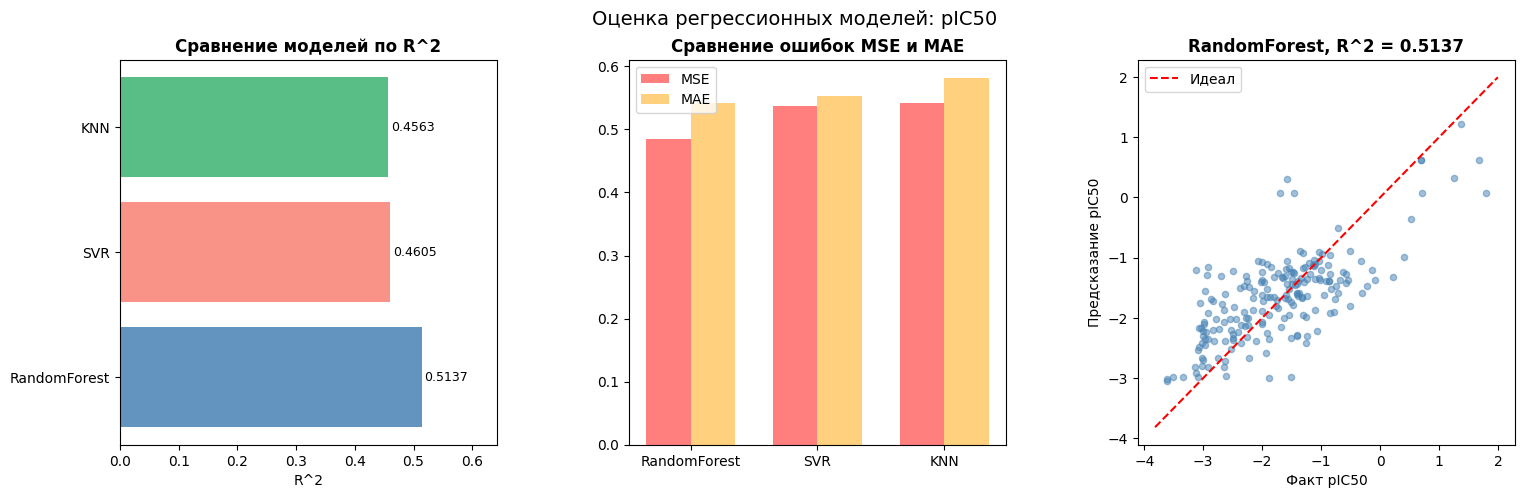

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.subplots_adjust(wspace=0.35)

colors = {'KNN': 'salmon', 'RandomForest': 'steelblue', 'SVR': 'mediumseagreen'}

#строим график сравнения моделей по коэффициенту детерминации
ax1 = axes[0]
bars = ax1.barh(results_df['Модель'], results_df['R^2'], color = ['steelblue', 'salmon', 'mediumseagreen'], alpha=0.85)
ax1.set_xlabel('R^2')
ax1.set_title('Сравнение моделей по R^2', fontweight = 'bold')
ax1.set_xlim(0, max(results_df['R^2']) * 1.25)
for bar, val in zip(bars, results_df['R^2']):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

#сравниваем модели по MSE и MAE
ax2 = axes[1]
x = np.arange(len(results_df))
width = 0.35
ax2.bar(x - width/2, results_df['MSE'], width, label = 'MSE', alpha=0.5, color = 'red')
ax2.bar(x + width/2, results_df['MAE'], width, label = 'MAE', alpha=0.5, color = 'orange')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Модель'])
ax2.set_title('Сравнение ошибок MSE и MAE', fontweight='bold')
ax2.legend()

#на основе предсказания лучшей модели строим график соответствия фактическому значению
best_name = results_df.iloc[0]['Модель']
y_pred_best = best_models[best_name].predict(X_test)

ax3 = axes[2]
ax3.scatter(y_test, y_pred_best, alpha = 0.5, s = 20, color = colors[best_name])
lims = [min(y_test.min(), y_pred_best.min()) - 0.2, max(y_test.max(), y_pred_best.max()) + 0.2]
ax3.plot(lims, lims, 'r--', lw=1.5, label='Идеал')
ax3.set_xlabel('Факт pIC50')
ax3.set_ylabel('Предсказание pIC50')
ax3.set_title(f'{best_name}, R^2 = {results_df.iloc[0]['R^2']:.4f}', fontweight = 'bold')
ax3.legend()

plt.suptitle('Оценка регрессионных моделей: pIC50', fontsize=14)
plt.show()

Вывод: RandomForest показал наилучший результат среди трех моделей, коэффициент детерминации = 0.51, однако умеренное качество предсказания объясняется сложностью задачи: линейные корреляции молекулярных дескрипторов с pIC50 слабы (max r = 0.27)

**Важность признаков в Random Forest**

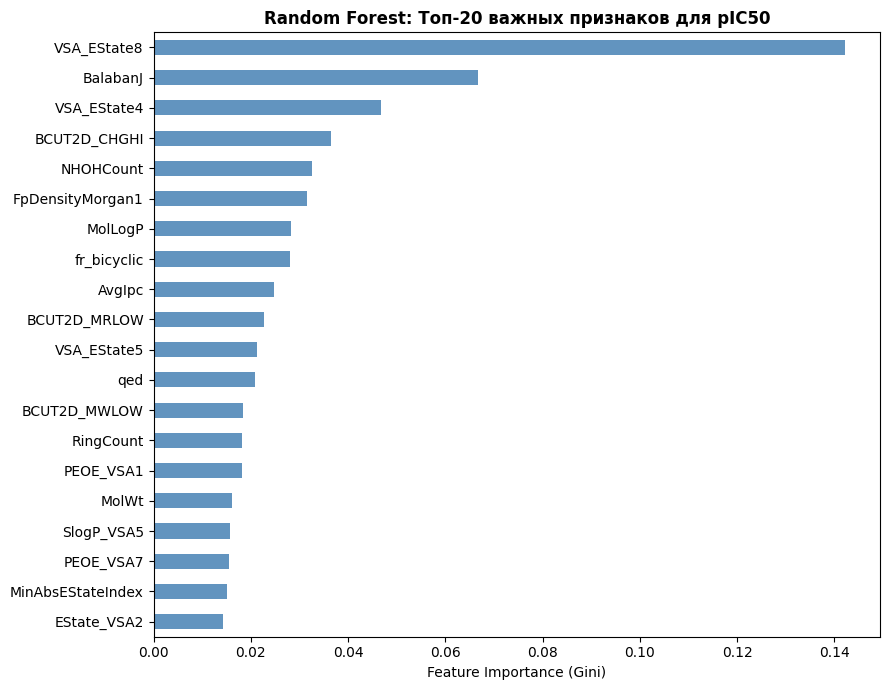

In [5]:
rf_model = best_models['RandomForest'].named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index = X.columns)
top20 = importances.sort_values(ascending = False).head(20)

plt.figure(figsize=(9, 7))
top20[::-1].plot(kind = 'barh', color = 'steelblue', alpha = 0.85)
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest: Топ-20 важных признаков для pIC50', fontweight = 'bold')
plt.tight_layout()
plt.show()

Вывод: по результатам экспериментов с тремя регрессионными алгоритмами Random Forest показал лучший результат, так как он справился с нелинейными зависимостями. Также модель наиболее устойчива к переобучению и дает интерпретируемый результат при данном объеме данных.

**Как можно улучшить:**
- собрать дополнительные данные для надежного ообобщения и предсказания
- использовать Feature selection на основе importance, чтобы дополнительно убрать мультиколлинеарность
- объединить модели RF и SVR. Из-за разнородности алгоритмов этих моделей, и ошибок разной природы они могут дать неплохую комбинацию